# Archivo para calcular rentabilidad de un portafolio

In [85]:
##### Modulos necesarios
import pandas as pd
import numpy as np
from tqdm import tqdm
import scipy
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Rentabilidad equilibrada

Por varias razones, una rentabilidad equilibrada es necesaria para medir diferences mas equitativamente. La formula es

$R_t = \sum_i^n \frac{\sigma_{tgt}}{\tilde{\sigma}_{i,t-1}} * w_{i,t-1} * r_{i,t} - C*\sum_i^n | \frac{\sigma_{tgt}}{\tilde{\sigma}_{i,t-1}} * w_{i,t-1} - \frac{\sigma_{tgt}}{\tilde{\sigma}_{i,t-2}} * w_{i,t-2} |$

Los requisitos para calcular esta rentabilidad son:
- Rendimientos: $r_{i,t}$
- Pesas del portafolio: $w_{i,t}$
- Exponentially Weighted Moving Standar Deviation (EWMSD): $\tilde{\sigma}_{i,t-1}$
- Constantes - volatilidad deseada $\sigma_{tgt}$ y costo de transacciones $C$

El EWMA generalmente se calcula en la siguiente manera:

$\text{EWMA}_t(x) = \alpha * x_t + (1-\alpha) * \text{EWMA}_{t-1}(x)$

Implicando que el EWMSD es:

$\tilde{\sigma}_{i,t} = \sqrt{\alpha(r_t-\mu_{t-1})^2 + (1-\alpha)\tilde{\sigma}_{t-1}^2}$


In [86]:
##### Funcion para integrar posiciones
def posiciones(df_r: pd.DataFrame, empresas: list[str], tipo:str):
    df_posiciones = pd.DataFrame()
    #### Extracciones individuales
    if tipo=='sliding':
        for i in range(22):
            tmp = scipy.io.loadmat(f'SlidingFinalPreds/pred_sliding_{i}.mat')
            df_tmp = pd.DataFrame(tmp['Ypred_final'])
            df_posiciones = pd.concat([df_posiciones, df_tmp], axis=0, ignore_index=True)
        del tmp
        df_posiciones.columns = [f'Posicion.{nom}' for nom in empresas]
    elif tipo=='expanding':
        for i in range(22):
            tmp = scipy.io.loadmat(f'ExpandingFinalPreds/pred_expanding_{i}.mat')
            df_tmp = pd.DataFrame(tmp['Ypred_final'])
            df_posiciones = pd.concat([df_posiciones, df_tmp], axis=0, ignore_index=True)
        del tmp
        df_posiciones.columns = [f'Posicion.{nom}' for nom in empresas]
    elif tipo=='todo':
        for nom in empresas:
            df_posiciones[f'Posicion.{nom}'] = [1] * df_r.shape[0]
    elif tipo=='rand':
        import random
        random.seed(42)
        for nom in empresas:
            df_posiciones[f'Posicion.{nom}'] = [random.randint(0,1) for _ in range(df_r.shape[0])]


    #### Asegurando que df_posiciones tenga mismo numero de datos
    df_posiciones = df_posiciones.iloc[:df_r.shape[0]]

    #### Camiando indices
    df_posiciones.index = df_r.index

    #### Sumando cantidad de posiciones
    suma = df_posiciones.sum(axis=1)

    #### Asignando posiciones equitativamente
    df_posiciones_finales = df_posiciones.div(suma, axis=0)

    #### Integrando posiciones con rendimientos
    df_integrado = pd.concat([df_r,df_posiciones_finales], axis=1, ignore_index=False)

    return df_integrado


In [87]:
##### Calculando formula para la rentabilidad del portafolio

def calc_rentabilidad(df:pd.Dataframe, empresas: list[str], tgt: int = 0.1, costo : int = 0.00001) -> pd.Dataframe:
    """
    Formula para calcular la rentabilidad de un portafolio 

    Params:
    df: el dataframe que contiene los rendimientos, EWMSD, y posiciones del portafolio
    tgt: la voltatilidad deseada para escalar la volatilidad proporcionalmente
    costo: costo de cambiar las posiciones de las acciones en un portafolio

    Return:
    df_rentabilidad: el df que contiene la rentabilidad del portafolio por las fechas marcadas
    """
    #### Calculando rentabilidad equitativa por cada accion/empresa
    df_rentabilidad = pd.DataFrame()
    for name in empresas:
        df_rentabilidad[f'Rentabilidad.{name}'] = df[name] * (tgt/df[f'EWMSD.{name}'].shift(1))  * df[f'Posicion.{name}'].shift(1) - \
        costo*abs(((tgt/df[f'EWMSD.{name}'].shift(1))*df[f'Posicion.{name}'].shift(1)) - ((tgt/df[f'EWMSD.{name}'].shift(2))*df[f'Posicion.{name}'].shift(2)))

    #### Elimando primera dos fila por el "shift(2)"
    df_rentabilidad = df_rentabilidad.iloc[2:]

    #### Sumando la rentabilidad de todas las acciones para calcular la rentabilidad diaria del portafolio
    df_rentabilidad_diaria = df_rentabilidad.sum(axis=1)

    return df_rentabilidad_diaria



In [88]:
##### Creando datos necesarios
#### Rendimientos, origiales y logs
df_rendis = pd.read_csv('retornos.csv', index_col='Date')
df_rendis_log = pd.read_csv('retornos_log_splac.csv',index_col='Date')

#### Nombre de las 32 empresas
empresas = df_rendis.columns.to_list()

#### Calculando EWMSD
for name in empresas:
    df_rendis[f'EWMSD.{name}'] = df_rendis[name].ewm(span=30, adjust=False).std()
    df_rendis_log[f'EWMSD.{name}'] = df_rendis_log[name].ewm(span=30, adjust=False).std()
    # df_rendis[f'EWMSD.{name}']  = [1] * df_rendis.shape[0]    #Debug
    # df_rendis[f'Posicion.{name}'] = [1] * df_rendis.shape[0]  #Posiciones falsas para debug
    # df_rendis[f'Rentabilidad.{name}'] = df_rendis[name] * (1/df_rendis[f'EWMSD.{name}'].shift(1))  *df_rendis[f'Posicion.{name}'].shift(1) - \
    # 1*abs(((1/df_rendis[f'EWMSD.{name}'].shift(1))*df_rendis[f'Posicion.{name}'].shift(1)) - ((1/df_rendis[f'EWMSD.{name}'].shift(2))*df_rendis[f'Posicion.{name}'].shift(2)))
    #     #Simulando rentabilidad calculacion

#### Eliminando datos
### Al crear la particion de los datos
    # Bajo "matlab_procesamiento", no se completo el ultimo conjunto porque solo tenia 62
            # dias y le faltaban 160 mas
df_rendis = df_rendis.iloc[:-62]
df_rendis_log = df_rendis_log.iloc[:-62]
### Al separar los datos en train/val/test
    # El trainset tiene 252 dias y el valset tiene 63
    # Adicionalmente, los siguiente 30 dias no se consideran porque se utilizaron para
            # crear la primera ventana del testset
    # Entonces los primeros 252 + 63 + 30 = 345 dias se eliminan
df_rendis = df_rendis.iloc[345:]
df_rendis_log = df_rendis_log.iloc[345:]



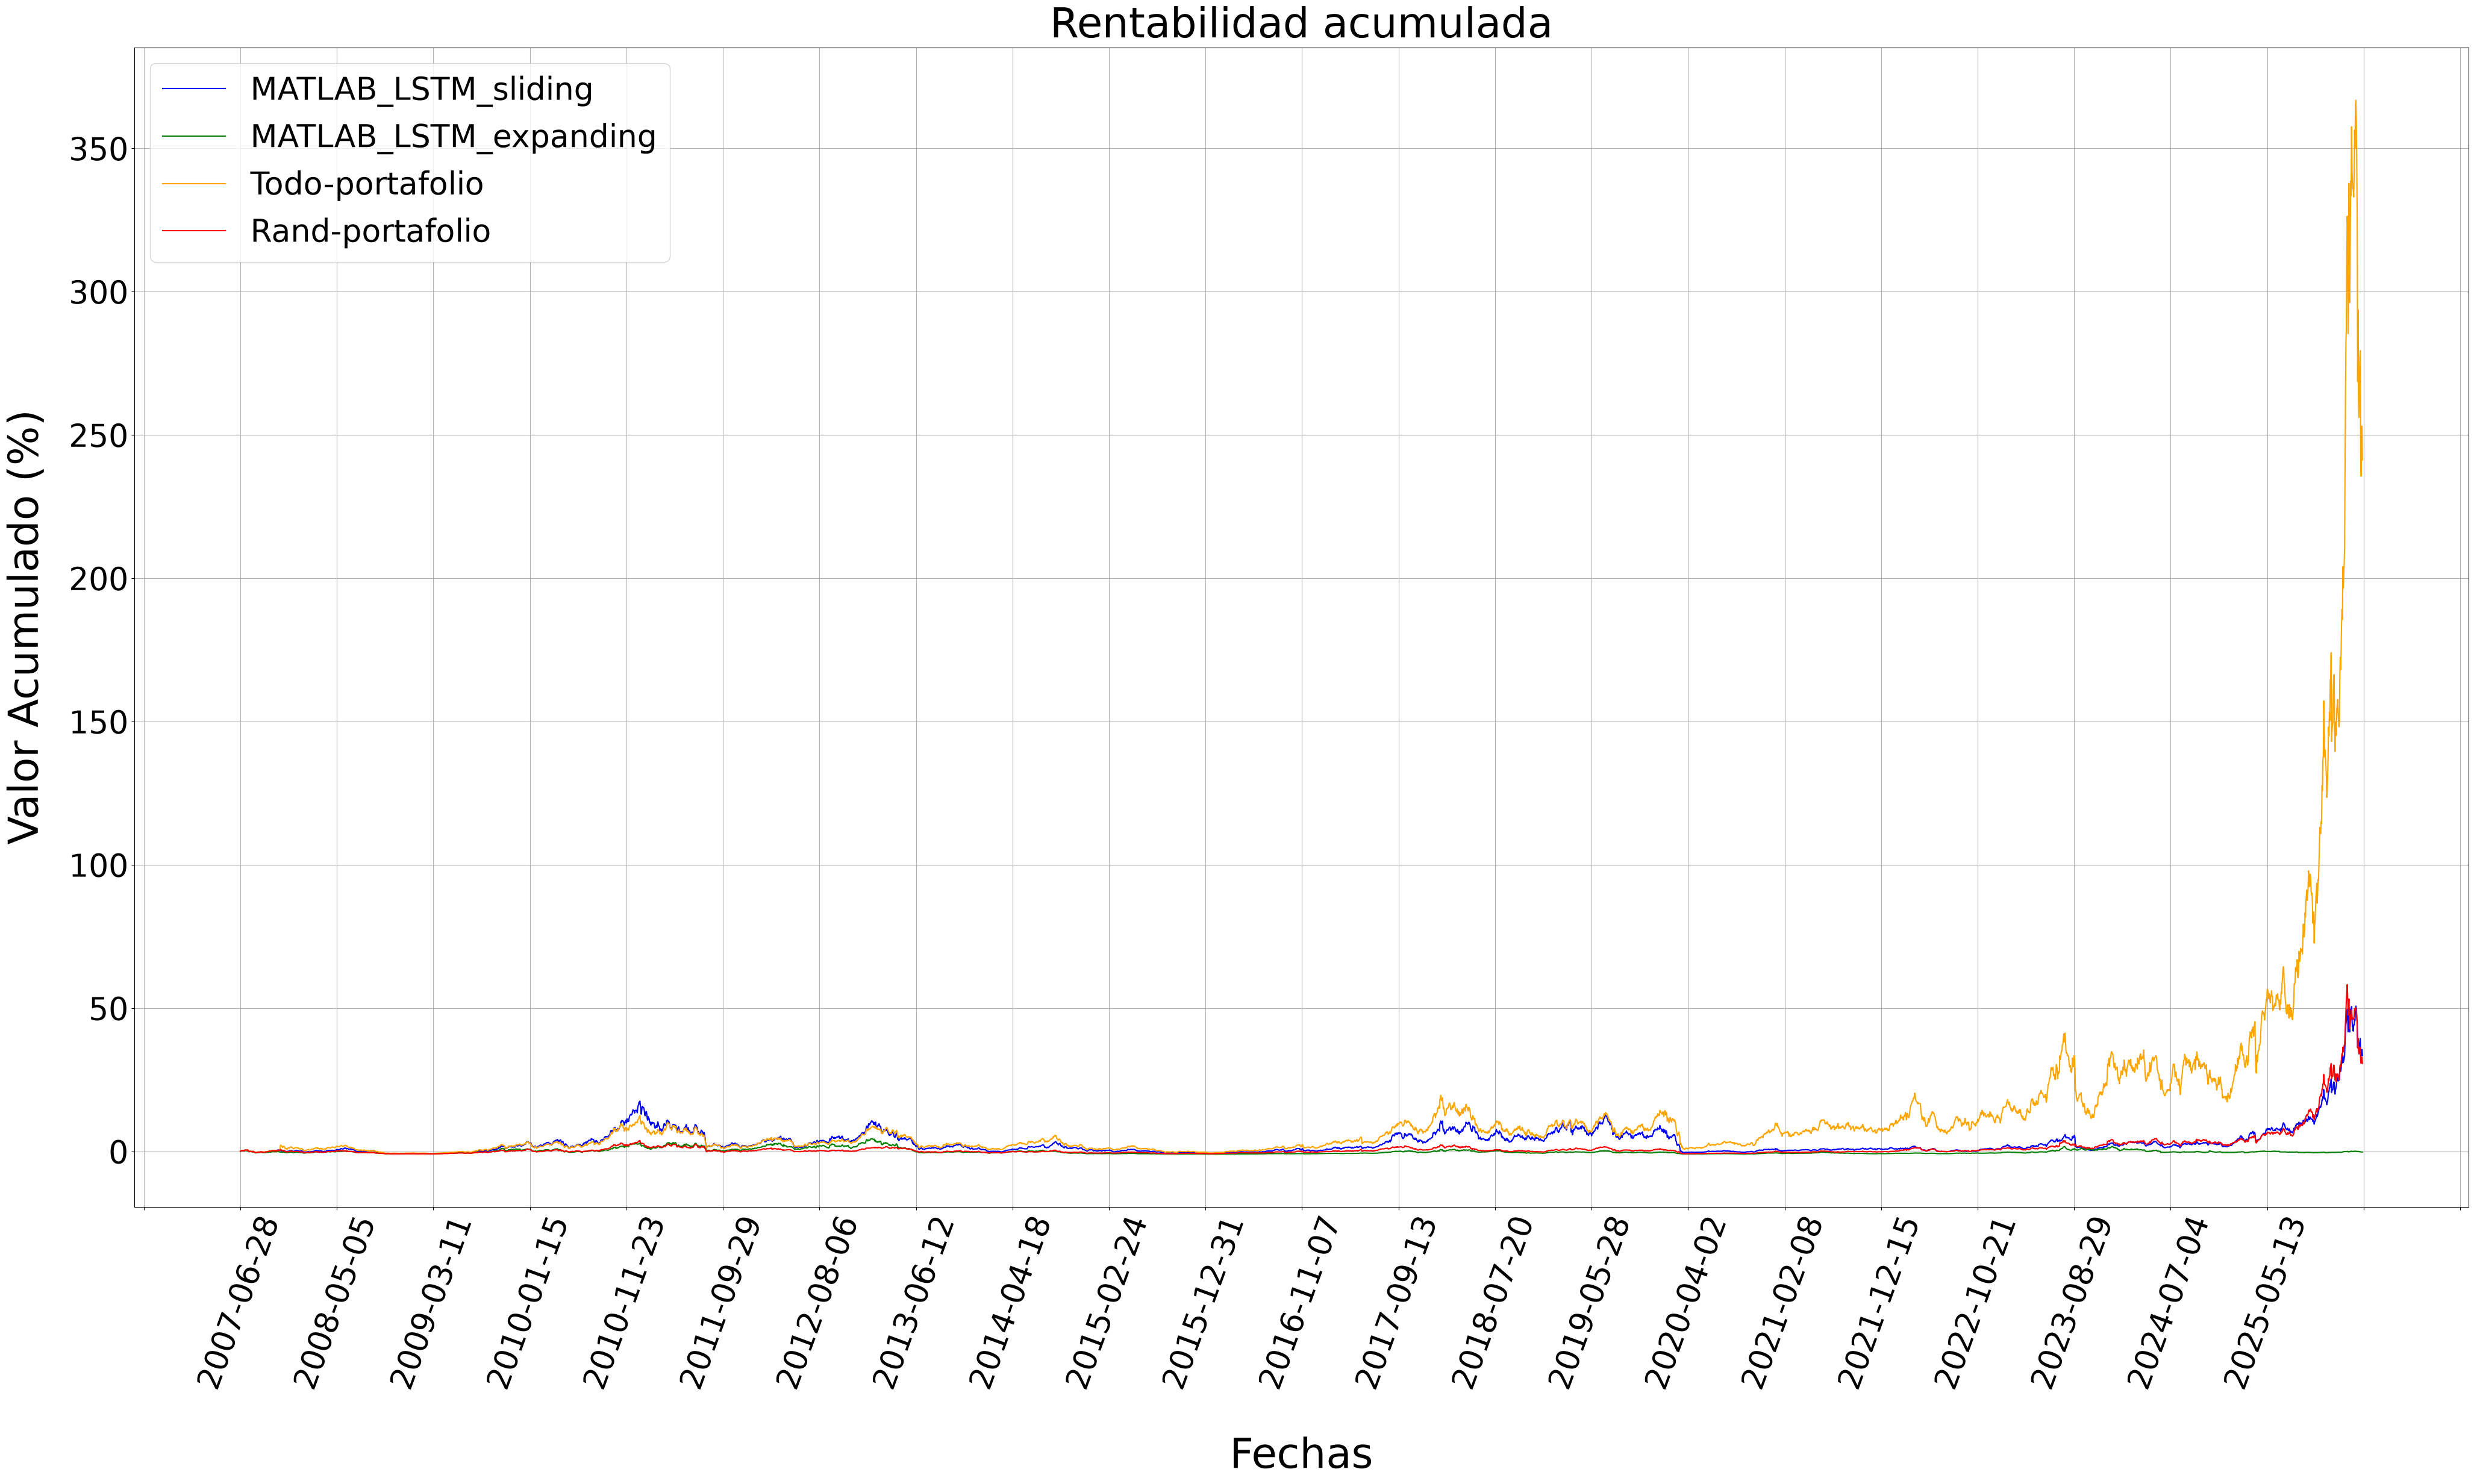

In [100]:
##### Analisis con rendimientos originales
#### Calculando posiciones
df_sliding = posiciones(df_rendis, empresas, 'sliding')
df_expanding = posiciones(df_rendis, empresas, 'expanding')
df_todo= posiciones(df_rendis, empresas, 'todo')
df_rand = posiciones(df_rendis, empresas, 'rand')

#### Calculado rentabilidades diarias
sliding_rentabilidad_diaria = calc_rentabilidad(df_sliding, empresas)
expanding_rentabilidad_diaria = calc_rentabilidad(df_expanding, empresas)
todo_rentabilidad_diaria = calc_rentabilidad(df_todo, empresas)
rand_rentabilidad_diaria = calc_rentabilidad(df_rand, empresas)

#### Calculando y trazando rentabilidad acumulada
### Calculacion
sliding_rentabilidad_acumulada = (1 + sliding_rentabilidad_diaria).cumprod() - 1
expanding_rentabilidad_acumulada = (1 + expanding_rentabilidad_diaria).cumprod() - 1
todo_rentabilidad_acumulada = (1 + todo_rentabilidad_diaria).cumprod() - 1
rand_rentabilidad_acumulada = (1 + rand_rentabilidad_diaria).cumprod() - 1


### Grafo
SALTO_X = 222   #252 test dias - 30 dias ventana tamano
ANCHURA = 50
ALTURA = 25

fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))

### Sliding_acumulada
ax.plot(
    sliding_rentabilidad_acumulada.index,
    sliding_rentabilidad_acumulada,
    color='blue',
    label = 'MATLAB_LSTM_sliding',
    linestyle = 'solid'
)

### Expanding acumulada
ax.plot(
    expanding_rentabilidad_acumulada.index,
    expanding_rentabilidad_acumulada,
    color='green',
    label = 'MATLAB_LSTM_expanding',
    linestyle = 'solid'
)

### Todo-portafolio acumulada
ax.plot(
    todo_rentabilidad_acumulada.index,
    todo_rentabilidad_acumulada,
    color='orange',
    label = 'Todo-portafolio',
    linestyle = 'solid'
)

### Rand-portafolio acumulada
ax.plot(
    rand_rentabilidad_acumulada.index,
    rand_rentabilidad_acumulada,
    color='red',
    label = 'Rand-portafolio',
    linestyle = 'solid'
)

### configuraciones
ax.set_title('Rentabilidad acumulada',fontsize = ANCHURA)
ax.set_ylabel('Valor Acumulado (%)', fontsize = ANCHURA, labelpad = ALTURA)
ax.set_xlabel('Fechas', fontsize =ANCHURA, labelpad = ANCHURA)
ax.tick_params(axis='x', labelsize=0.75*ANCHURA, rotation=70) 
ax.tick_params(axis='y', labelsize=0.75*ANCHURA) 
ax.xaxis.set_major_locator(MultipleLocator(SALTO_X))
ax.legend(fontsize = 0.75*ANCHURA)
ax.grid(True)


plt.show()





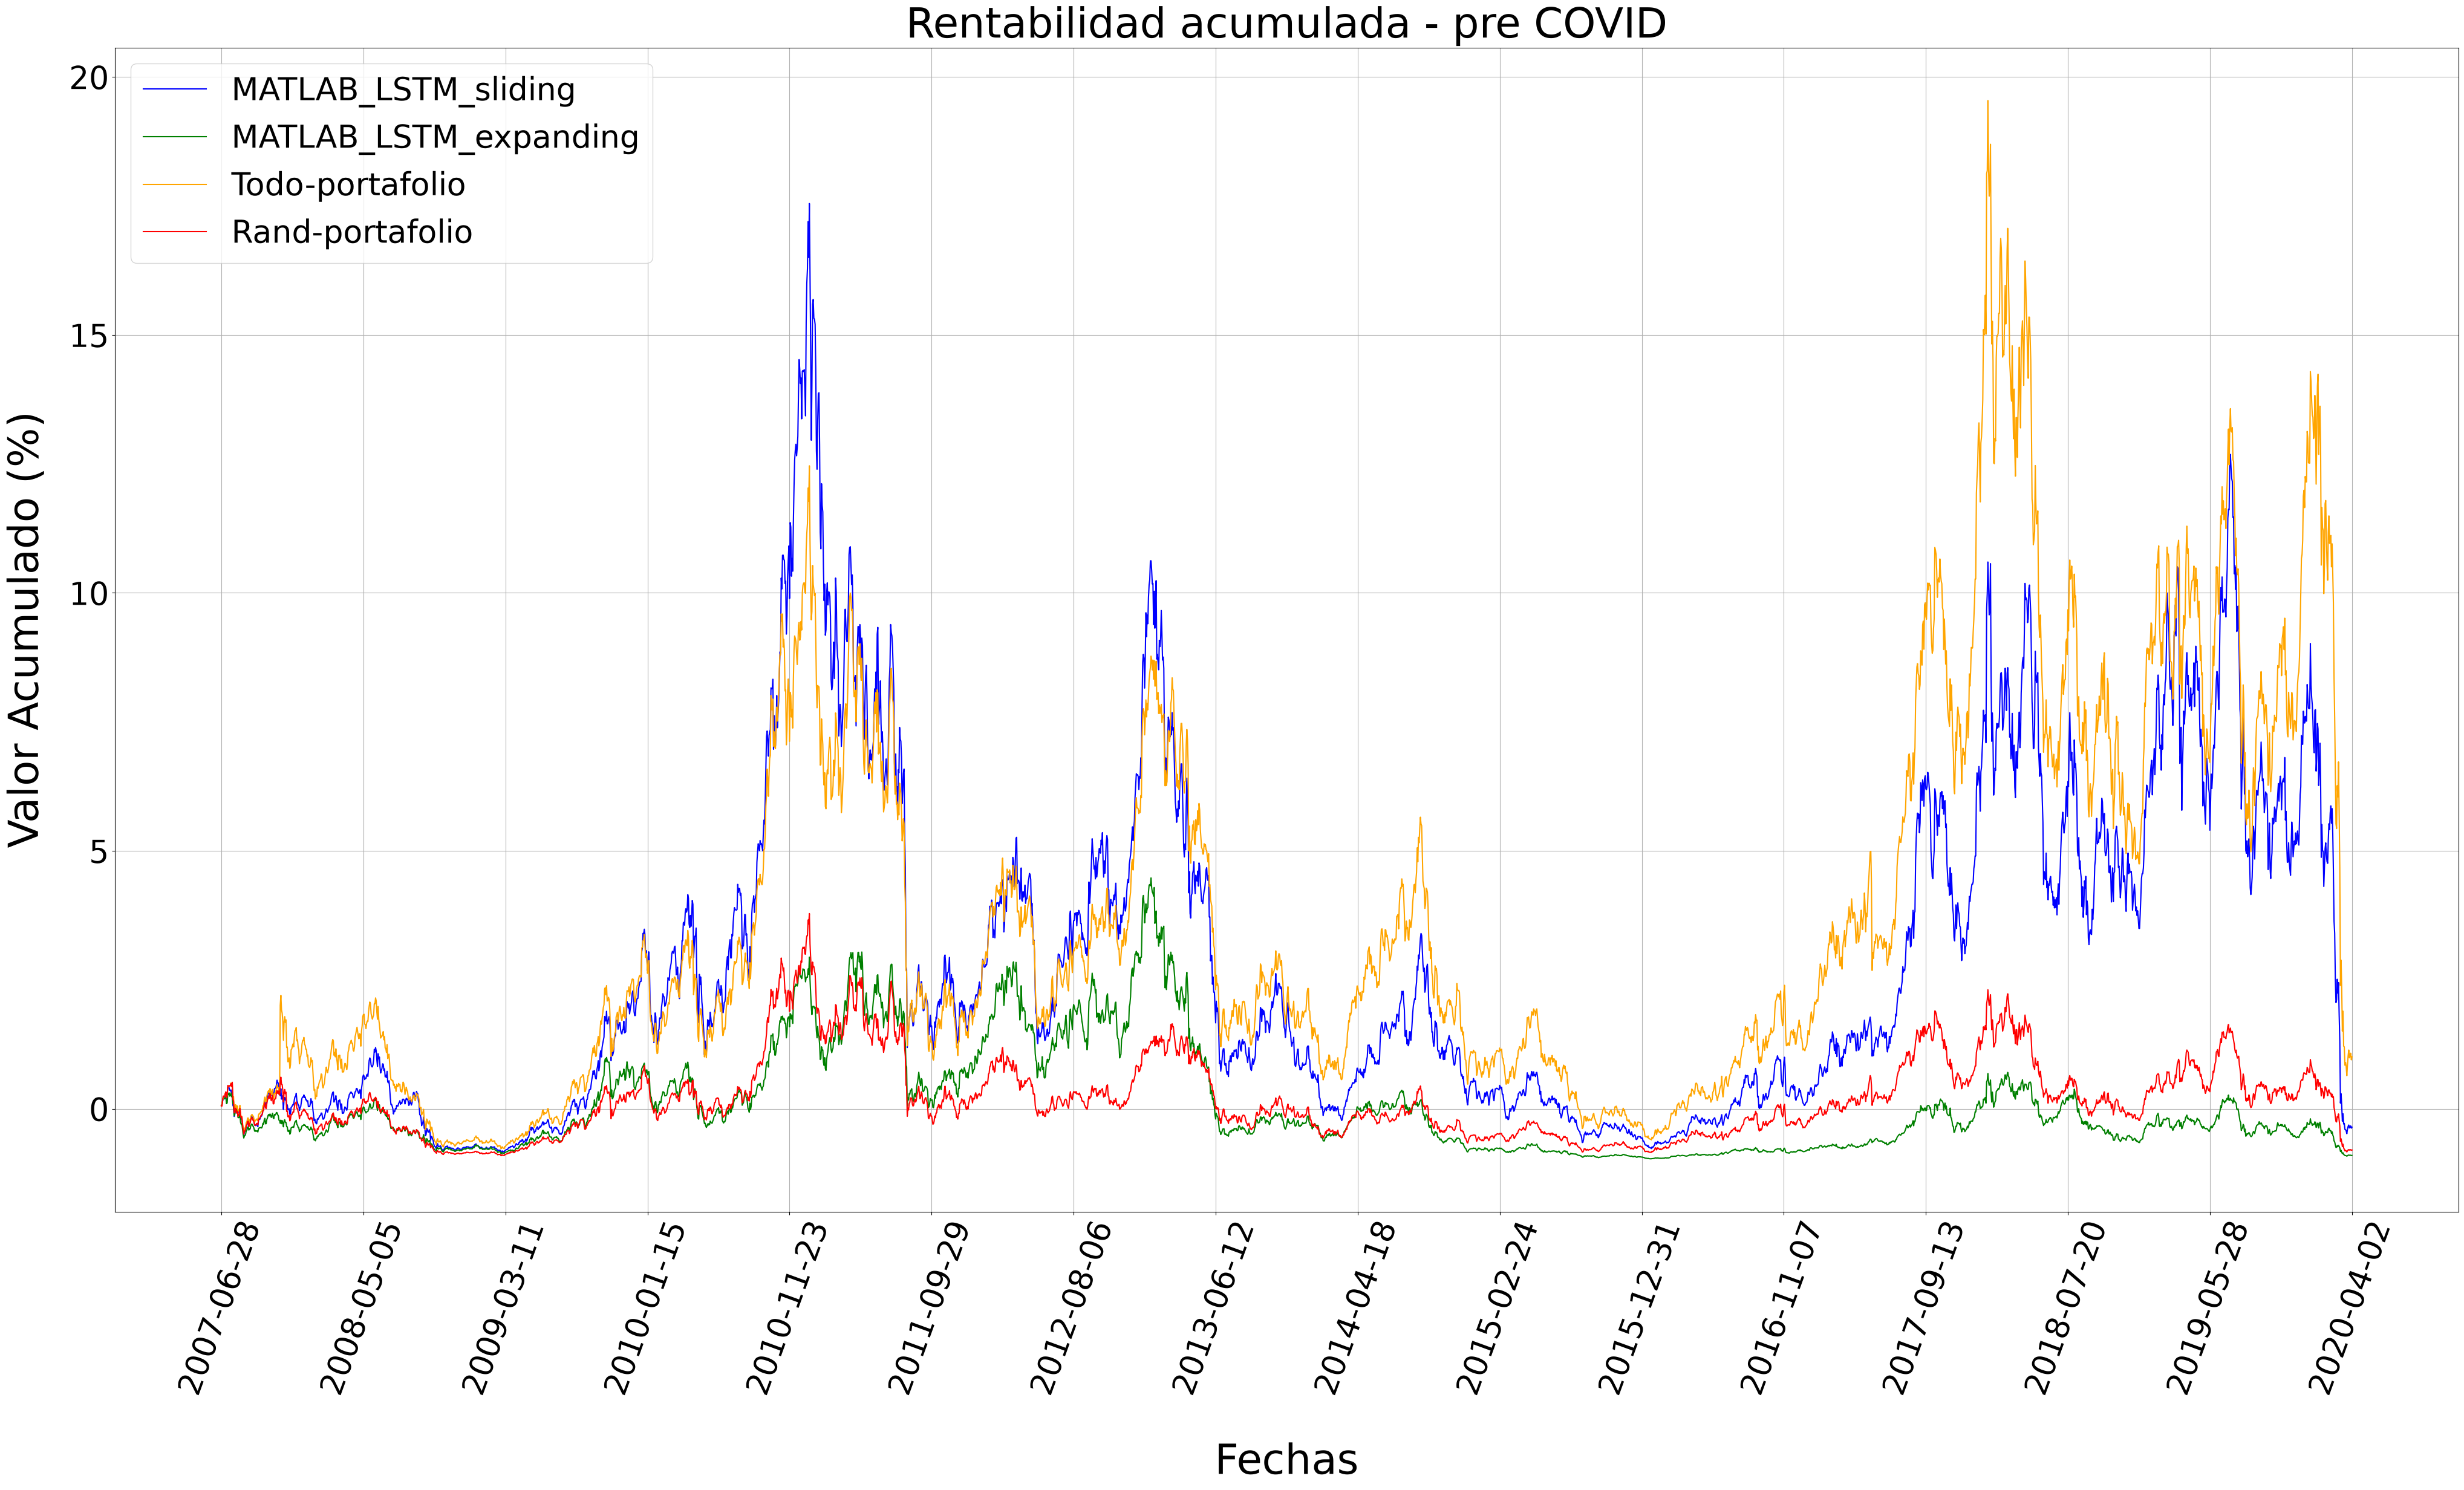

In [101]:
##### Analisis antes COVID
#### Calculando posiciones
df_sliding = posiciones(df_rendis, empresas, 'sliding')
df_expanding = posiciones(df_rendis, empresas, 'expanding')
df_todo= posiciones(df_rendis, empresas, 'todo')
df_rand = posiciones(df_rendis, empresas, 'rand')

#### Calculado rentabilidades diarias
sliding_rentabilidad_diaria = calc_rentabilidad(df_sliding, empresas)
expanding_rentabilidad_diaria = calc_rentabilidad(df_expanding, empresas)
todo_rentabilidad_diaria = calc_rentabilidad(df_todo, empresas)
rand_rentabilidad_diaria = calc_rentabilidad(df_rand, empresas)

#### Calculando y trazando rentabilidad acumulada
### Calculacion
sliding_rentabilidad_acumulada = (1 + sliding_rentabilidad_diaria).cumprod() - 1
expanding_rentabilidad_acumulada = (1 + expanding_rentabilidad_diaria).cumprod() - 1
todo_rentabilidad_acumulada = (1 + todo_rentabilidad_diaria).cumprod() - 1
rand_rentabilidad_acumulada = (1 + rand_rentabilidad_diaria).cumprod() - 1


### Grafo
SALTO_X = 222   #252 test dias - 30 dias ventana tamano
ANCHURA = 50
ALTURA = 25

fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))

### Sliding_acumulada
ax.plot(
    sliding_rentabilidad_acumulada.loc[:"2020-04-02"].index,
    sliding_rentabilidad_acumulada.loc[:"2020-04-02"],
    color='blue',
    label = 'MATLAB_LSTM_sliding',
    linestyle = 'solid'
)

### Expanding acumulada
ax.plot(
    expanding_rentabilidad_acumulada.loc[:"2020-04-02"].index,
    expanding_rentabilidad_acumulada.loc[:"2020-04-02"],
    color='green',
    label = 'MATLAB_LSTM_expanding',
    linestyle = 'solid'
)

### Todo-portafolio acumulada
ax.plot(
    todo_rentabilidad_acumulada.loc[:"2020-04-02"].index,
    todo_rentabilidad_acumulada.loc[:"2020-04-02"],
    color='orange',
    label = 'Todo-portafolio',
    linestyle = 'solid'
)

### Rand-portafolio acumulada
ax.plot(
    rand_rentabilidad_acumulada.loc[:"2020-04-02"].index,
    rand_rentabilidad_acumulada.loc[:"2020-04-02"],
    color='red',
    label = 'Rand-portafolio',
    linestyle = 'solid'
)

### configuraciones
ax.set_title('Rentabilidad acumulada - pre COVID',fontsize = ANCHURA)
ax.set_ylabel('Valor Acumulado (%)', fontsize = ANCHURA, labelpad = ALTURA)
ax.set_xlabel('Fechas', fontsize =ANCHURA, labelpad = ANCHURA)
ax.tick_params(axis='x', labelsize=0.75*ANCHURA, rotation=70) 
ax.tick_params(axis='y', labelsize=0.75*ANCHURA) 
ax.xaxis.set_major_locator(MultipleLocator(SALTO_X))
ax.legend(fontsize = 0.75*ANCHURA)
ax.grid(True)


plt.show()






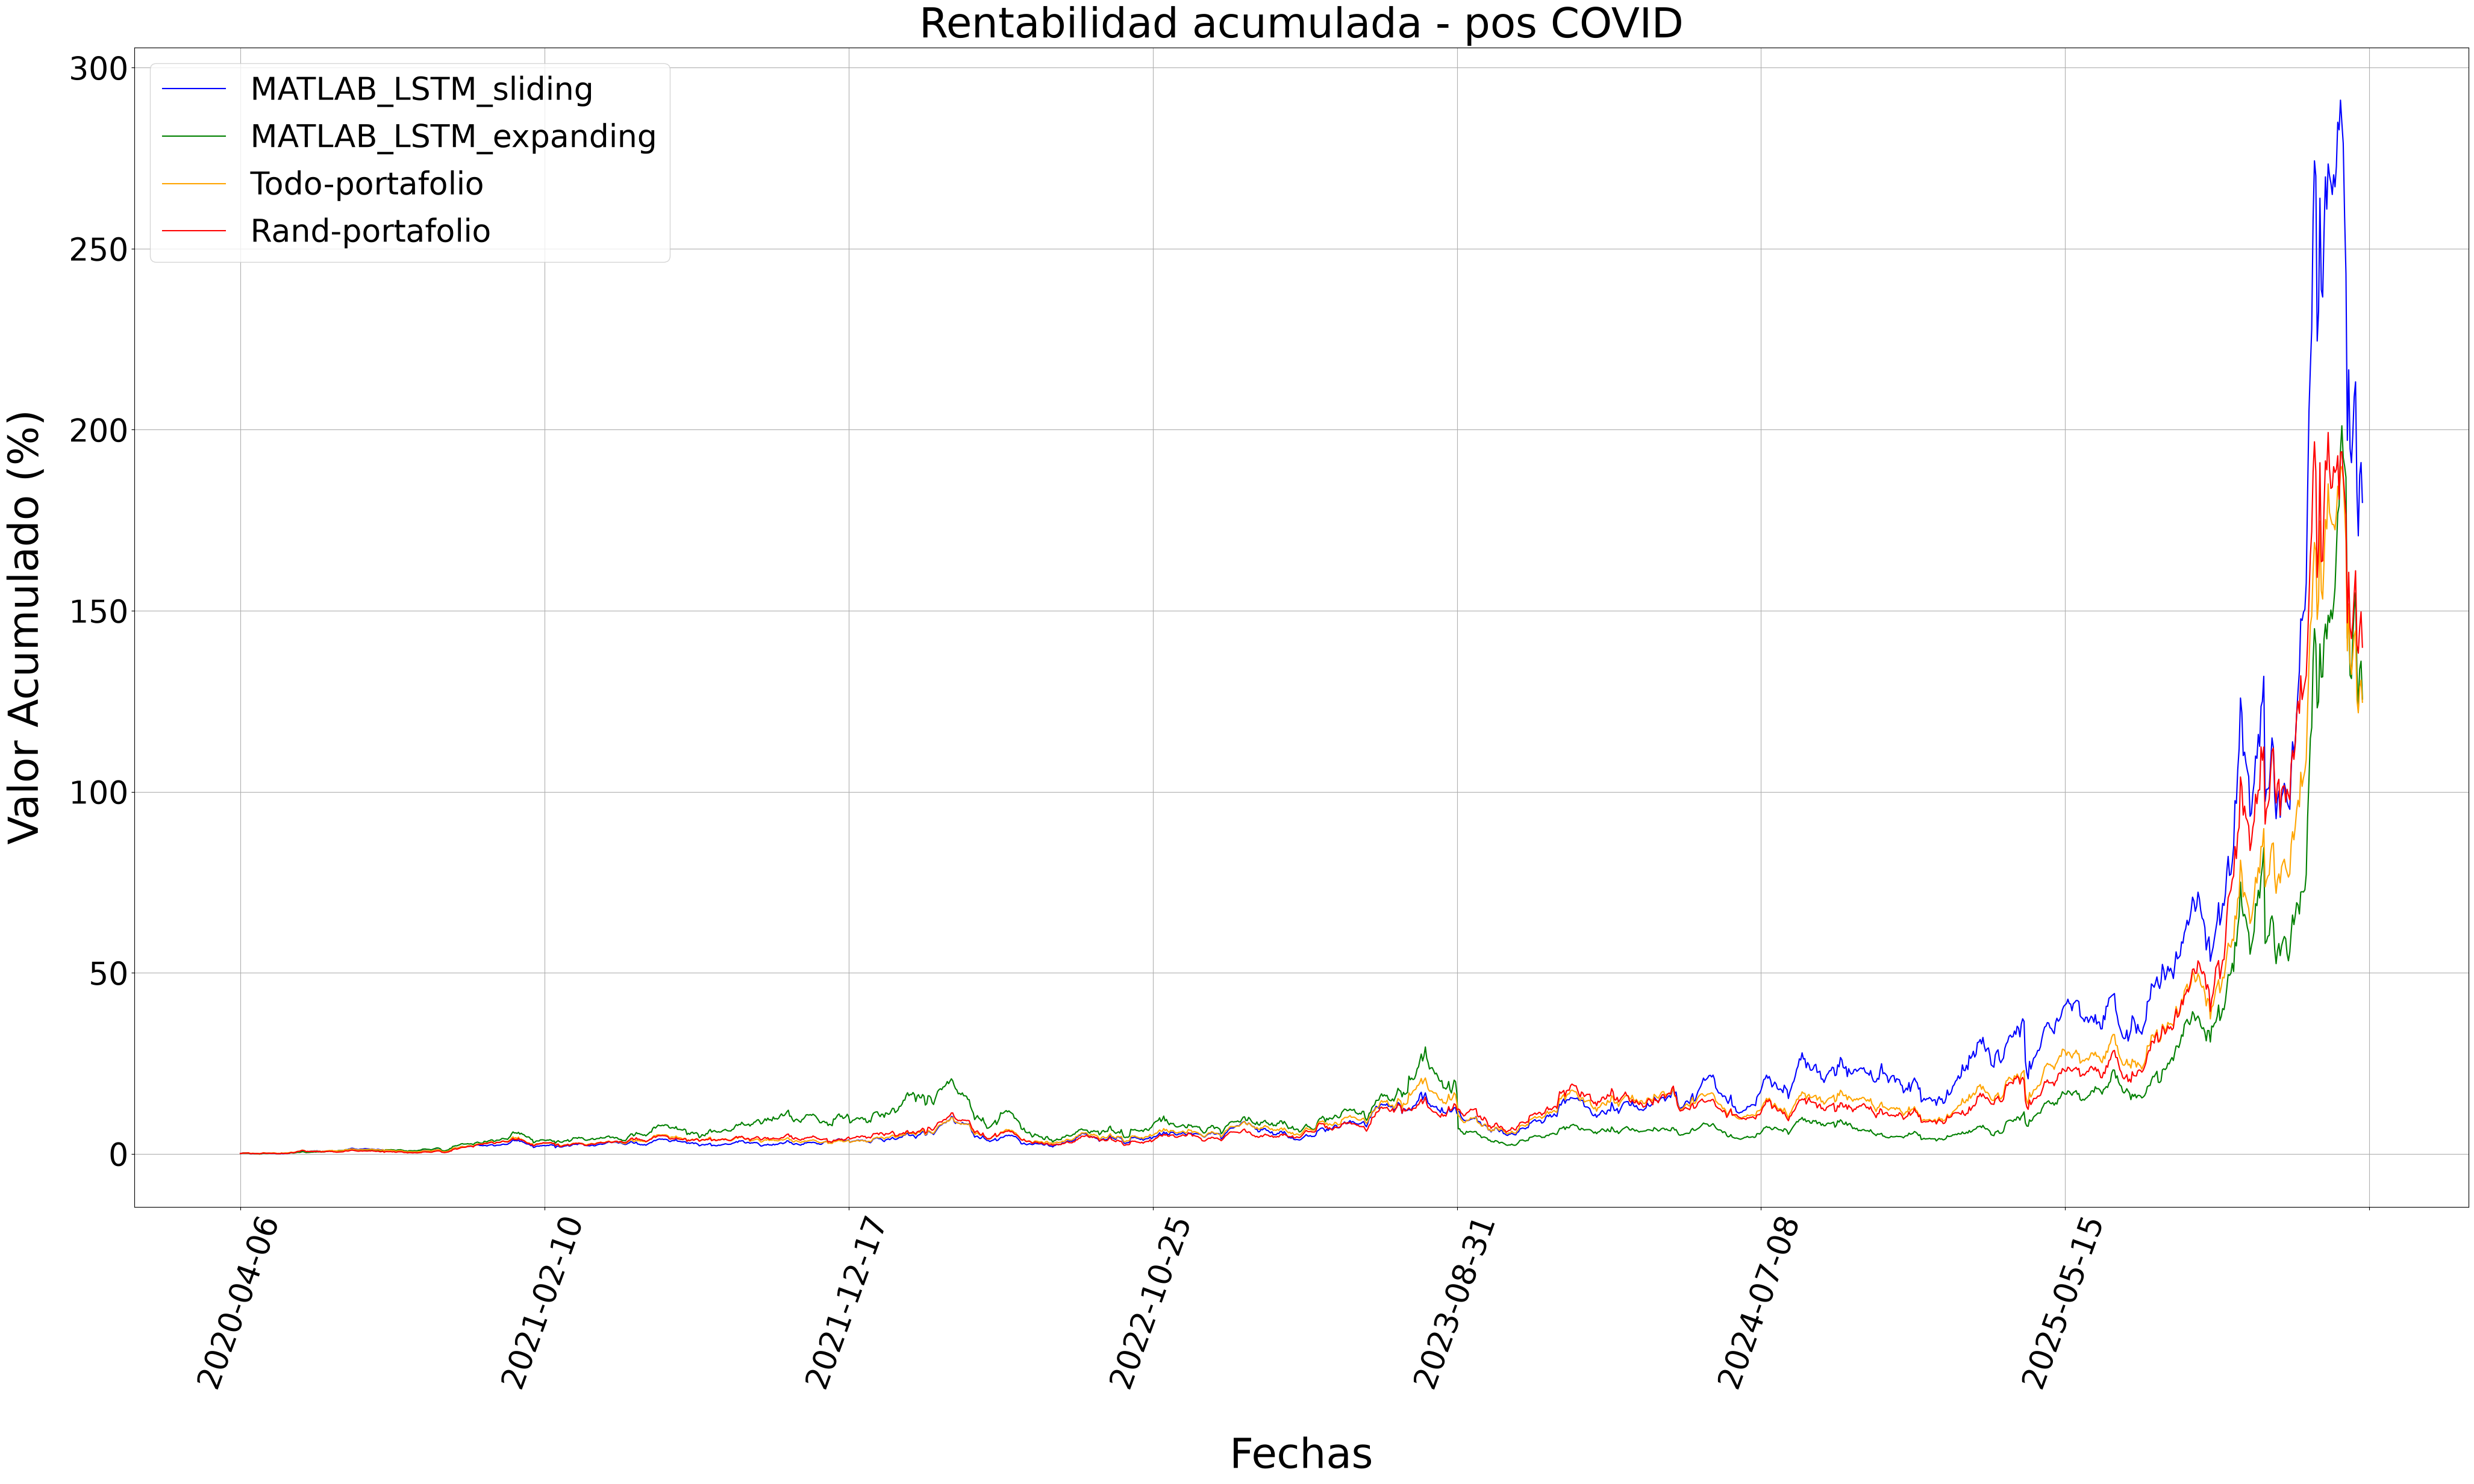

In [ ]:
##### Analisis post COVID
#### Calculando posiciones
df_sliding = posiciones(df_rendis, empresas, 'sliding')
df_expanding = posiciones(df_rendis, empresas, 'expanding')
df_todo= posiciones(df_rendis, empresas, 'todo')
df_rand = posiciones(df_rendis, empresas, 'rand')

#### Calculado rentabilidades diarias
sliding_rentabilidad_diaria = calc_rentabilidad(df_sliding, empresas)
expanding_rentabilidad_diaria = calc_rentabilidad(df_expanding, empresas)
todo_rentabilidad_diaria = calc_rentabilidad(df_todo, empresas)
rand_rentabilidad_diaria = calc_rentabilidad(df_rand, empresas)

#### Calculando y trazando rentabilidad acumulada
### Calculacion
sliding_rentabilidad_acumulada = (1 + sliding_rentabilidad_diaria).cumprod() - 1
expanding_rentabilidad_acumulada = (1 + expanding_rentabilidad_diaria).cumprod() - 1
todo_rentabilidad_acumulada = (1 + todo_rentabilidad_diaria).cumprod() - 1
rand_rentabilidad_acumulada = (1 + rand_rentabilidad_diaria).cumprod() - 1


### Grafo
SALTO_X = 222   #252 test dias - 30 dias ventana tamano
ANCHURA = 50
ALTURA = 25

fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))

### Sliding_acumulada
ax.plot(
    sliding_rentabilidad_acumulada.loc["2020-04-02":].index,
    sliding_rentabilidad_acumulada.loc["2020-04-02":],
    color='blue',
    label = 'MATLAB_LSTM_sliding',
    linestyle = 'solid'
)

### Expanding acumulada
ax.plot(
    expanding_rentabilidad_acumulada.loc["2020-04-02":].index,
    expanding_rentabilidad_acumulada.loc["2020-04-02":],
    color='green',
    label = 'MATLAB_LSTM_expanding',
    linestyle = 'solid'
)

### Todo-portafolio acumulada
ax.plot(
    todo_rentabilidad_acumulada.loc["2020-04-02":].index,
    todo_rentabilidad_acumulada.loc["2020-04-02":],
    color='orange',
    label = 'Todo-portafolio',
    linestyle = 'solid'
)

### Rand-portafolio acumulada
ax.plot(
    rand_rentabilidad_acumulada.loc["2020-04-02":].index,
    rand_rentabilidad_acumulada.loc["2020-04-02":],
    color='red',
    label = 'Rand-portafolio',
    linestyle = 'solid'
)

### configuraciones
ax.set_title('Rentabilidad acumulada - pos COVID',fontsize = ANCHURA)
ax.set_ylabel('Valor Acumulado (%)', fontsize = ANCHURA, labelpad = ALTURA)
ax.set_xlabel('Fechas', fontsize =ANCHURA, labelpad = ANCHURA)
ax.tick_params(axis='x', labelsize=0.75*ANCHURA, rotation=70) 
ax.tick_params(axis='y', labelsize=0.75*ANCHURA) 
ax.xaxis.set_major_locator(MultipleLocator(SALTO_X))
ax.legend(fontsize = 0.75*ANCHURA)
ax.grid(True)


plt.show()






In [91]:
# ##### Tranzando rentabilidad diaria
# #### Grafo
# SALTO_X = 222   #252 test dias - 30 dias ventana tamano
# ANCHURA = 50
# ALTURA = 25

# fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))

# #### Sliding_acumulada
# ax.plot(
#     sliding_rentabilidad_diaria.index,
#     sliding_rentabilidad_diaria,
#     color='blue',
#     label = 'MATLAB_LSTM_sliding',
#     linestyle = 'solid'
# )

# #### Expanding acumulada
# ax.plot(
#     expanding_rentabilidad_diaria.index,
#     expanding_rentabilidad_diaria,
#     color='green',
#     label = 'MATLAB_LSTM_expanding',
#     linestyle = 'solid'
# )

# # #### Todo-portafolio acumulada
# # ax.plot(
# #     todo_rentabilidad_diaria.index,
# #     todo_rentabilidad_diaria,
# #     color='orange',
# #     label = 'Todo-portafolio',
# #     linestyle = 'solid'
# # )

# #### Rand-portafolio acumulada
# ax.plot(
#     rand_rentabilidad_diaria.index,
#     rand_rentabilidad_diaria,
#     color='red',
#     label = 'Rand-portafolio',
#     linestyle = 'solid'
# )


# ax.set_title('Rentabilidad diaria',fontsize = ANCHURA)
# ax.set_ylabel('Valor Acumulado (%)', fontsize = ANCHURA, labelpad = ALTURA)
# ax.set_xlabel('Fechas', fontsize =ANCHURA, labelpad = ANCHURA)
# ax.tick_params(axis='x', labelsize=0.75*ANCHURA, rotation=70) 
# ax.tick_params(axis='y', labelsize=0.75*ANCHURA) 
# ax.xaxis.set_major_locator(MultipleLocator(SALTO_X))
# ax.legend(fontsize = 0.75*ANCHURA)
# ax.grid(True)

# plt.show()

In [92]:
# ##### Analisis con rendimientos logaritmicos
# #### Calculando posiciones
# df_sliding = posiciones(df_rendis_log, empresas, 'sliding')
# df_expanding = posiciones(df_rendis_log, empresas, 'expanding')
# df_todo= posiciones(df_rendis_log, empresas, 'todo')
# df_rand = posiciones(df_rendis_log, empresas, 'rand')

# #### Calculado rentabilidades diarias
# sliding_rentabilidad_diaria = calc_rentabilidad(df_sliding, empresas)
# expanding_rentabilidad_diaria = calc_rentabilidad(df_expanding, empresas)
# todo_rentabilidad_diaria = calc_rentabilidad(df_todo, empresas)
# rand_rentabilidad_diaria = calc_rentabilidad(df_rand, empresas)

# #### Calculando y trazando rentabilidad acumulada
# ### Calculacion
# sliding_rentabilidad_acumulada = (1 + sliding_rentabilidad_diaria).cumprod() - 1
# expanding_rentabilidad_acumulada = (1 + expanding_rentabilidad_diaria).cumprod() - 1
# todo_rentabilidad_acumulada = (1 + todo_rentabilidad_diaria).cumprod() - 1
# rand_rentabilidad_acumulada = (1 + rand_rentabilidad_diaria).cumprod() - 1


# ### Grafo
# SALTO_X = 222   #252 test dias - 30 dias ventana tamano
# ANCHURA = 50
# ALTURA = 25

# fig, ax = plt.subplots(figsize=(ANCHURA, ALTURA))

# ### Sliding_acumulada
# ax.plot(
#     sliding_rentabilidad_acumulada.index,
#     sliding_rentabilidad_acumulada,
#     color='blue',
#     label = 'MATLAB_LSTM_sliding',
#     linestyle = 'solid'
# )

# ### Expanding acumulada
# ax.plot(
#     expanding_rentabilidad_acumulada.index,
#     expanding_rentabilidad_acumulada,
#     color='green',
#     label = 'MATLAB_LSTM_expanding',
#     linestyle = 'solid'
# )

# ### Todo-portafolio acumulada
# ax.plot(
#     todo_rentabilidad_acumulada.index,
#     todo_rentabilidad_acumulada,
#     color='orange',
#     label = 'Todo-portafolio',
#     linestyle = 'solid'
# )

# ### Rand-portafolio acumulada
# ax.plot(
#     rand_rentabilidad_acumulada.index,
#     rand_rentabilidad_acumulada,
#     color='red',
#     label = 'Rand-portafolio',
#     linestyle = 'solid'
# )

# ### configuraciones
# ax.set_title('Rentabilidad logaritmica acumulada',fontsize = ANCHURA)
# ax.set_ylabel('Valor Acumulado (%)', fontsize = ANCHURA, labelpad = ALTURA)
# ax.set_xlabel('Fechas', fontsize =ANCHURA, labelpad = ANCHURA)
# ax.tick_params(axis='x', labelsize=0.75*ANCHURA, rotation=70) 
# ax.tick_params(axis='y', labelsize=0.75*ANCHURA) 
# ax.xaxis.set_major_locator(MultipleLocator(SALTO_X))
# ax.legend(fontsize = 0.75*ANCHURA)
# ax.grid(True)

# plt.show()





In [93]:
# ##### DEBUG ---- Creando datos necesarios
# #### Rendimientos
# df_rendis = pd.read_csv('retornos.csv', index_col='Date')

# empresas = df_rendis.columns.to_list()
# print(empresas)
# sums = df_rendis.sum(axis=1)
# display(sums)

# #### EWMSD
# # df = pd.DataFrame({'valor': [10, 20, 15, 25, 30]})
# # resultado = df.ewm(span=30, adjust=False).std()

# for name in df_rendis.columns:
#     # df_rendis[f'EWMSD.{name}'] = df_rendis[name].ewm(span=30, adjust=False).std()   # Verdadero
#     df_rendis[f'EWMSD.{name}']  = [1] * df_rendis.shape[0]  #Debug
#     df_rendis[f'Posicion.{name}'] = [1] * df_rendis.shape[0]  #Debug

# # display(df_rendis.head())

# #Form 1
# form1 = pd.DataFrame(index=df_rendis.index)
# # for name in empresas:
# #     form1[name] = df_rendis[name]*df_rendis[f'Posicion.{name}'].shift(2)

# # display(form1.sum(axis=1))

# # Form 2
# # for name in empresas:
# #     form1[name] = df_rendis[name] * (0.1/df_rendis[f'EWMSD.{name}'].shift(3))  *df_rendis[f'Posicion.{name}'].shift(2)


# # display(form1.sum(axis=1))


# # Form 4
# for name in empresas:
#     form1[name] = df_rendis[name] * (1/df_rendis[f'EWMSD.{name}'].shift(1))  *df_rendis[f'Posicion.{name}'].shift(1) - \
#     1*abs(((1/df_rendis[f'EWMSD.{name}'].shift(1))*df_rendis[f'Posicion.{name}'].shift(1)) - ((1/df_rendis[f'EWMSD.{name}'].shift(2))*df_rendis[f'Posicion.{name}'].shift(2)))

# display(form1.sum(axis=1))
